=== CONFUSION MATRIX ANALYSIS FOR ReLU MODEL ===
Loading MNIST data...


C:\Users\User\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Training data shape: (60000, 784)
Test data shape: (10000, 784)

Training ReLU model for confusion matrix analysis...
Epoch 1/5: Loss: 0.2600, Accuracy: 0.9236
Epoch 2/5: Loss: 0.1263, Accuracy: 0.9628
Epoch 3/5: Loss: 0.0911, Accuracy: 0.9732
Epoch 4/5: Loss: 0.0719, Accuracy: 0.9791
Epoch 5/5: Loss: 0.0586, Accuracy: 0.9827

Generating predictions and confusion matrix...


C:\Users\User\AppData\Local\Temp\ipykernel_34416\841032572.py:155: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_34416\841032572.py:157: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


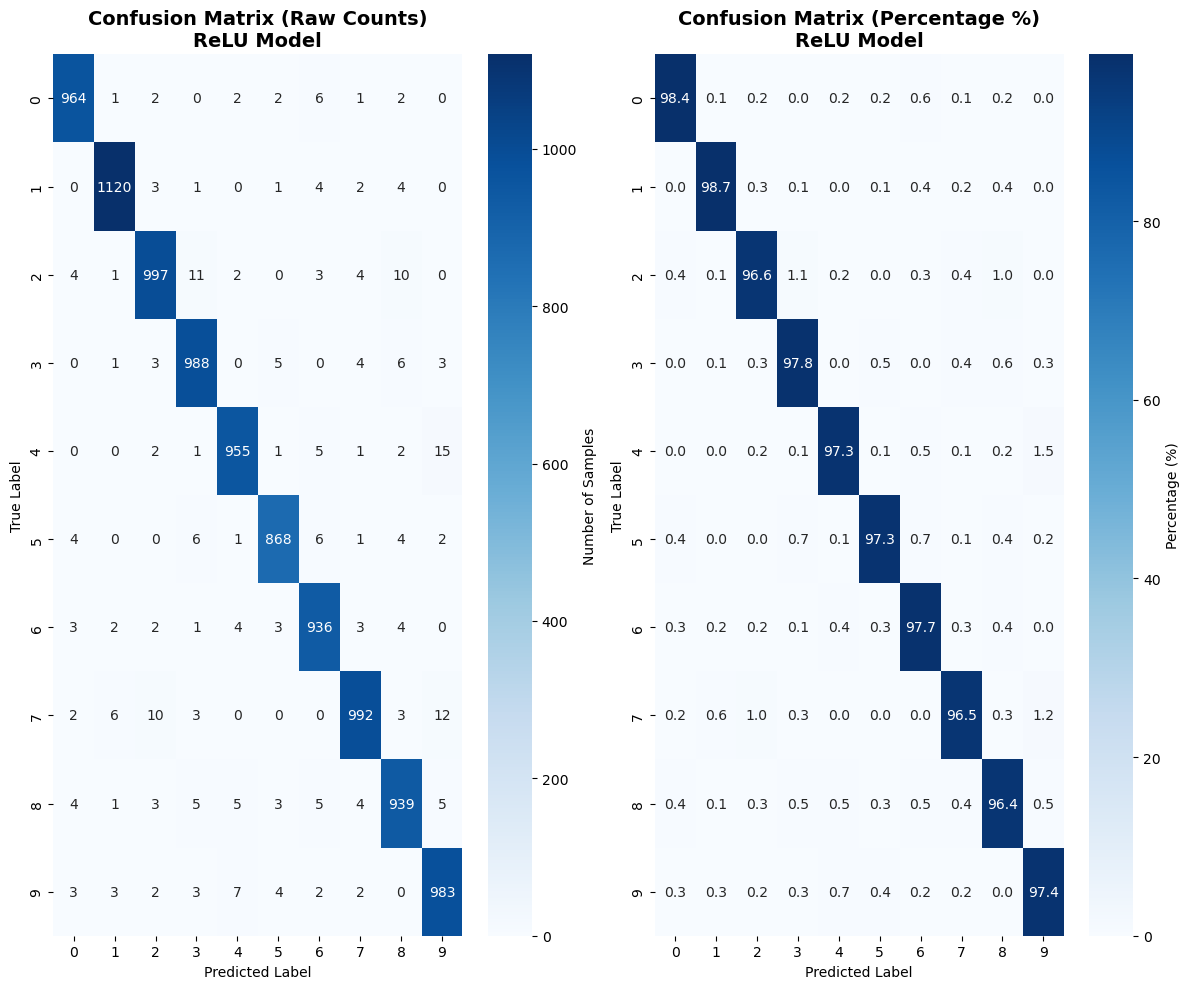


MISCLASSIFICATION ANALYSIS
Class 0: 964/980 correct (98.37%)
Class 1: 1120/1135 correct (98.68%)
Class 2: 997/1032 correct (96.61%)
Class 3: 988/1010 correct (97.82%)
Class 4: 955/982 correct (97.25%)
Class 5: 868/892 correct (97.31%)
Class 6: 936/958 correct (97.70%)
Class 7: 992/1028 correct (96.50%)
Class 8: 939/974 correct (96.41%)
Class 9: 983/1009 correct (97.42%)

1. MOST MISLABELED GROUND TRUTH CLASS: 8
   Accuracy: 96.41%

2. CLASS PAIR CAUSING MOST CONFUSION:
   True class 4 is most often misclassified as class 9
   Number of misclassifications: 15
   This represents 1.53% of all class 4 samples

3. TOP 3 MOST CONFUSING CLASS PAIRS:
   1. True 4 → Predicted 9: 15 samples (1.53%)
   2. True 7 → Predicted 9: 12 samples (1.17%)
   3. True 2 → Predicted 3: 11 samples (1.07%)

OVERALL TEST ACCURACY: 97.42%


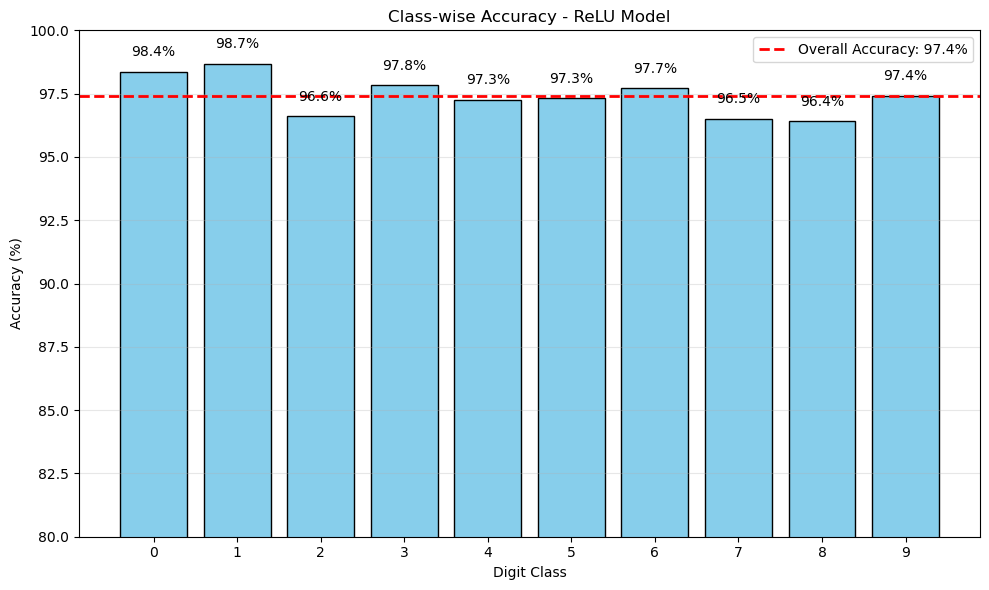


4. VISUALIZING CONFUSION: Class 4 vs Class 9


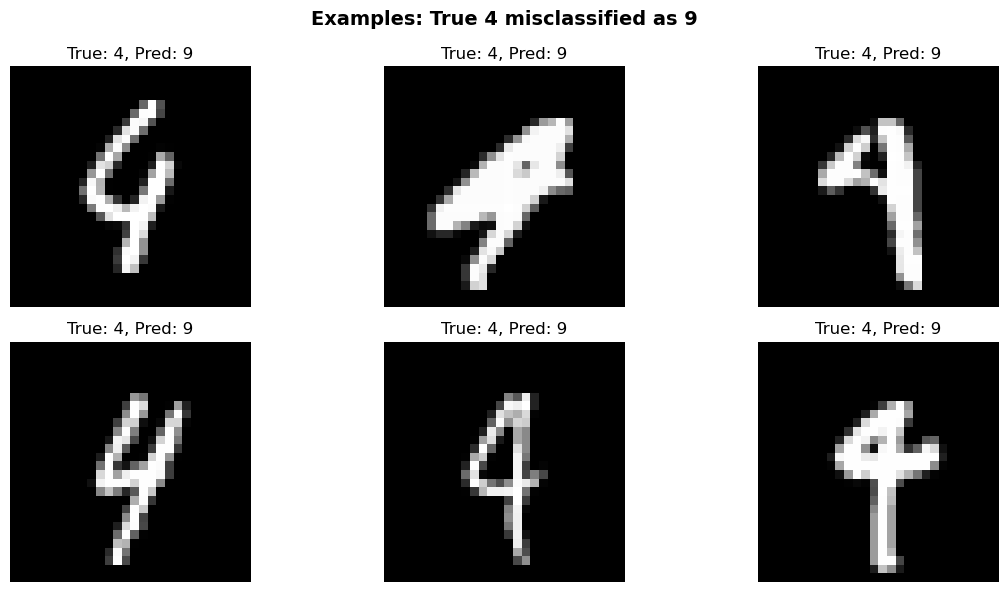

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import seaborn as sns

print("=== CONFUSION MATRIX ANALYSIS FOR ReLU MODEL ===")

# Load MNIST data
print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Split into train and test
X_train = X[:60000] / 255.0
X_test = X[60000:] / 255.0
y_train = y[:60000]
y_test = y[60000:]

# Normalize data
train_mean = np.mean(X_train)
train_std = np.std(X_train)
X_train_normalized = (X_train - train_mean) / train_std
X_test_normalized = (X_test - train_mean) / train_std

print(f"Training data shape: {X_train_normalized.shape}")
print(f"Test data shape: {X_test_normalized.shape}")

# Network parameters
d = 784  # input dimension
h = 128  # hidden units
k = 10   # output classes

# Load or retrain the ReLU model (using the same training code as before)
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

# Initialize weights with He initialization for ReLU
W1 = np.random.randn(h, d) * np.sqrt(2.0 / d)
W2 = np.random.randn(k, h) * np.sqrt(2.0 / h)

# Training parameters
learning_rate = 1e-3
batch_size = 1
epochs = 5

print("\nTraining ReLU model for confusion matrix analysis...")
for epoch in range(epochs):
    epoch_loss = 0
    epoch_correct = 0
    num_batches = 0
    
    # Shuffle training data
    indices = np.random.permutation(len(X_train_normalized))
    X_epoch = X_train_normalized[indices]
    y_epoch = y_train[indices]
    
    for i in range(0, len(X_epoch), batch_size):
        x = X_epoch[i].reshape(-1, 1)
        y_label = y_epoch[i]
        
        # Convert to one-hot for training
        y_onehot = np.zeros((10, 1))
        y_onehot[y_label] = 1
        
        # Forward pass
        a1 = W1 @ x
        h1 = relu(a1)
        a2 = W2 @ h1
        y_hat = softmax(a2)
        
        # Compute loss and accuracy
        loss = -np.sum(y_onehot * np.log(y_hat + 1e-8))
        epoch_loss += loss
        predicted_class = np.argmax(y_hat)
        if predicted_class == y_label:
            epoch_correct += 1
        
        # Backward pass
        delta2 = y_hat - y_onehot
        dW2 = delta2 @ h1.T
        
        delta_h = W2.T @ delta2
        relu_deriv = relu_derivative(a1)
        delta1 = delta_h * relu_deriv
        dW1 = delta1 @ x.T
        
        # Update weights
        W2 -= learning_rate * dW2
        W1 -= learning_rate * dW1
        
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    accuracy = epoch_correct / num_batches
    print(f"Epoch {epoch+1}/{epochs}: Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

# Generate predictions and build confusion matrix
print("\nGenerating predictions and confusion matrix...")
confusion_matrix = np.zeros((10, 10), dtype=int)
all_predictions = []
all_true_labels = []

for i in range(len(X_test_normalized)):
    x = X_test_normalized[i].reshape(-1, 1)
    true_label = y_test[i]
    
    # Forward pass only
    a1 = W1 @ x
    h1 = relu(a1)
    a2 = W2 @ h1
    y_hat = softmax(a2)
    
    predicted_label = np.argmax(y_hat)
    
    # Update confusion matrix
    confusion_matrix[true_label, predicted_label] += 1
    all_predictions.append(predicted_label)
    all_true_labels.append(true_label)

# Convert to percentages for better visualization
confusion_matrix_percent = confusion_matrix.astype(float)
for i in range(10):
    row_sum = np.sum(confusion_matrix[i])
    if row_sum > 0:
        confusion_matrix_percent[i] = (confusion_matrix[i] / row_sum) * 100

# Plot confusion matrix
plt.figure(figsize=(12, 10))

# Plot 1: Raw counts
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Number of Samples'})
plt.title('Confusion Matrix (Raw Counts)\nReLU Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

# Plot 2: Percentage
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Percentage (%)'})
plt.title('Confusion Matrix (Percentage %)\nReLU Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.tight_layout()
plt.show()

# Analyze misclassifications
print("\n" + "="*70)
print("MISCLASSIFICATION ANALYSIS")
print("="*70)

# Calculate class-wise accuracy
class_accuracy = []
for i in range(10):
    correct = confusion_matrix[i, i]
    total = np.sum(confusion_matrix[i])
    accuracy = (correct / total) * 100 if total > 0 else 0
    class_accuracy.append(accuracy)
    print(f"Class {i}: {correct}/{total} correct ({accuracy:.2f}%)")

# Find most mislabeled ground truth class
worst_accuracy = min(class_accuracy)
worst_class = class_accuracy.index(worst_accuracy)
print(f"\n1. MOST MISLABELED GROUND TRUTH CLASS: {worst_class}")
print(f"   Accuracy: {worst_accuracy:.2f}%")

# Find the most confusing class pair
max_misclassification = 0
most_confusing_pair = (0, 0)

for i in range(10):
    for j in range(10):
        if i != j:  # Only consider off-diagonal elements
            if confusion_matrix[i, j] > max_misclassification:
                max_misclassification = confusion_matrix[i, j]
                most_confusing_pair = (i, j)

true_class, predicted_class = most_confusing_pair
print(f"\n2. CLASS PAIR CAUSING MOST CONFUSION:")
print(f"   True class {true_class} is most often misclassified as class {predicted_class}")
print(f"   Number of misclassifications: {max_misclassification}")

# Calculate percentage for this confusion
total_class_samples = np.sum(confusion_matrix[true_class])
misclassification_percent = (max_misclassification / total_class_samples) * 100
print(f"   This represents {misclassification_percent:.2f}% of all class {true_class} samples")

# Additional analysis: Top 3 most confusing pairs
print(f"\n3. TOP 3 MOST CONFUSING CLASS PAIRS:")
confusing_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confusing_pairs.append((i, j, confusion_matrix[i, j]))

# Sort by number of misclassifications
confusing_pairs.sort(key=lambda x: x[2], reverse=True)

for idx, (true_cls, pred_cls, count) in enumerate(confusing_pairs[:3]):
    percent = (count / np.sum(confusion_matrix[true_cls])) * 100
    print(f"   {idx+1}. True {true_cls} → Predicted {pred_cls}: {count} samples ({percent:.2f}%)")

# Calculate overall accuracy
total_correct = np.trace(confusion_matrix)
total_samples = np.sum(confusion_matrix)
overall_accuracy = (total_correct / total_samples) * 100
print(f"\nOVERALL TEST ACCURACY: {overall_accuracy:.2f}%")

# Plot class-wise accuracy
plt.figure(figsize=(10, 6))
classes = range(10)
plt.bar(classes, class_accuracy, color='skyblue', edgecolor='black')
plt.axhline(y=overall_accuracy, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Accuracy: {overall_accuracy:.1f}%')
plt.xlabel('Digit Class')
plt.ylabel('Accuracy (%)')
plt.title('Class-wise Accuracy - ReLU Model')
plt.xticks(classes)
plt.ylim(80, 100)
plt.grid(True, axis='y', alpha=0.3)
plt.legend()

# Add value labels on bars
for i, acc in enumerate(class_accuracy):
    plt.text(i, acc + 0.5, f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Visualize some examples of the most confusing pair
print(f"\n4. VISUALIZING CONFUSION: Class {most_confusing_pair[0]} vs Class {most_confusing_pair[1]}")
confusion_examples = []
for i in range(len(X_test_normalized)):
    if all_true_labels[i] == most_confusing_pair[0] and all_predictions[i] == most_confusing_pair[1]:
        confusion_examples.append(i)
    if len(confusion_examples) >= 6:  # Show 6 examples
        break

if confusion_examples:
    plt.figure(figsize=(12, 6))
    for idx, example_idx in enumerate(confusion_examples):
        plt.subplot(2, 3, idx + 1)
        img = X_test[example_idx].reshape(28, 28)
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {most_confusing_pair[0]}, Pred: {most_confusing_pair[1]}')
        plt.axis('off')
    plt.suptitle(f'Examples: True {most_confusing_pair[0]} misclassified as {most_confusing_pair[1]}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()